In [4]:
import numpy as np
import cv2

import PIL.Image as Image
import os

import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_hub as hub

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [7]:
import tensorflow as tf
import tensorflow_hub as hub
import keras
import sys

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("TensorFlow Hub:", hub.__version__)
print("Keras:", keras.__version__)

Python: 3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]
TensorFlow: 2.21.0
TensorFlow Hub: 0.16.1
Keras: 3.14.1


In [8]:
IMAGE_SHAPE = (224, 224)
classifier = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=True,
    input_shape=(224,224,3)
)

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [10]:
print(os.getcwd())

C:\Users\farah\repos\SoC_2026\week_3\codes


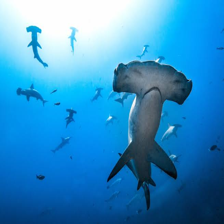

In [22]:
hammer_head = Image.open("hammerhead.jpg").resize(IMAGE_SHAPE)
hammer_head

In [23]:
hammer_head=np.array(hammer_head)/255.0
hammer_head.shape

(224, 224, 3)

In [28]:
result=classifier.predict(hammer_head[np.newaxis, ...])
result.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


(1, 1000)

In [25]:
predicted_label_index=np.argmax(result)
predicted_label_index

np.int64(4)

In [26]:
image_labels = []
with open("ImageNetLabels.txt", "r") as f:
    image_labels = f.read().splitlines()
image_labels = image_labels[1:]
image_labels[:5]

['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']

In [27]:
image_labels[predicted_label_index]

'hammerhead'

## flowers dataset

In [29]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)

In [30]:
data_dir

'.\\datasets\\flower_photos'

In [33]:
import pathlib
data_dir=pathlib.Path(data_dir)/'flower_photos'
data_dir

WindowsPath('datasets/flower_photos/flower_photos')

In [34]:
list(data_dir.glob('*/*.jpg'))[:5]

[WindowsPath('datasets/flower_photos/flower_photos/daisy/100080576_f52e8ee070_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10140303196_b88d3d6cec.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172379554_b296050f82_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172567486_2748826a8b.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172636503_21bededa75_n.jpg')]

In [35]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


In [36]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*.jpg')),
    'daisy': list(data_dir.glob('daisy/*.jpg')),
    'dandelion': list(data_dir.glob('dandelion/*.jpg')),
    'sunflowers': list(data_dir.glob('sunflowers/*.jpg')),
    'tulips': list(data_dir.glob('tulips/*.jpg')),
}

In [37]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [38]:
X, y = [], []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(224,224))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [39]:
X = np.array(X)
y = np.array(y)

In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [61]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

X_train_scaled = preprocess_input(X_train)
X_test_scaled = preprocess_input(X_test)

In [45]:
X[0].shape

(224, 224, 3)

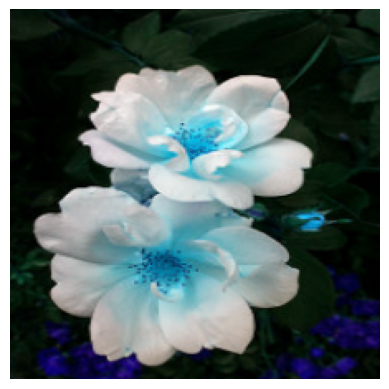

In [44]:
plt.axis('off')
plt.imshow(X[0])

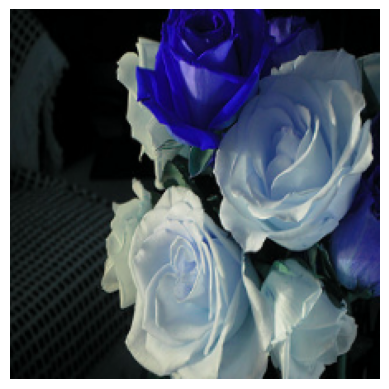

In [46]:
plt.axis('off')
plt.imshow(X[1])

In [49]:
predicted = classifier.predict(np.array([X[0],X[1],X[2]]))
predicted = np.argmax(predicted, axis=1)
predicted

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([794, 721, 443])

In [52]:
image_labels[443]

'bib'

In [62]:
pretrained_model_without_top_layer = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3),
)
pretrained_model_without_top_layer.trainable = False

In [63]:
num_of_flowers = 5

model = tf.keras.Sequential([
  pretrained_model_without_top_layer,
  tf.keras.layers.GlobalAveragePooling2D(),
  tf.keras.layers.Dense(num_of_flowers)
])
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 5)                   │           6,405 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [64]:
model.compile(
  optimizer="adam",
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['acc'])

model.fit(X_train_scaled, y_train, epochs=5)

Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 57s 567ms/step - acc: 0.6842 - loss: 0.8272
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 46s 529ms/step - acc: 0.8532 - loss: 0.4258
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 45s 527ms/step - acc: 0.8895 - loss: 0.3347
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 85s 556ms/step - acc: 0.9110 - loss: 0.2789
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 45s 525ms/step - acc: 0.9310 - loss: 0.2380


In [65]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 555ms/step - acc: 0.8693 - loss: 0.3506


[0.35061123967170715, 0.8692810535430908]